# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [64]:
from pyexpat import features

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

In [65]:
df = pd.read_csv('phone_addiction.csv', encoding='latin-1')

In [66]:
df = df.dropna(subset=['addiction_level'])

In [67]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,coffee_per_day,breaks_per_day,night_usage,distraction_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,7.377325,290.254742,NaN,2.0,1.0,0.0,7.852,Medium,29.587834
1,34.0,3.82,2.33,0.28,7.612689,270.571074,93.65,1.0,3.0,0.0,7.146,Medium,17.320665
2,29.0,3.57,1.64,5.21,6.143298,134.054219,100.00,0.0,5.0,0.0,2.962,Low,75.183980
3,25.0,10.27,4.37,4.28,4.012145,233.019834,94.71,2.0,2.0,1.0,8.791,Medium,31.133161
4,22.0,2.42,1.60,3.67,6.953253,19.381791,100.00,0.0,3.0,0.0,0.669,Low,54.640676


In [68]:
df = df.drop(columns=['age'])

In [69]:
target_column = 'addiction_level'

In [70]:
X = df.drop(columns=[target_column])
y = df[target_column]

In [71]:
X

,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,coffee_per_day,breaks_per_day,night_usage,distraction_score,productivity_score
0,5.950000,2.810000,2.610000,7.377325,290.254742,NaN,2.000000,1.000000,0.0,7.852000,29.587834
1,3.820000,2.330000,0.280000,7.612689,270.571074,93.650000,1.000000,3.000000,0.0,7.146000,17.320665
2,3.570000,1.640000,5.210000,6.143298,134.054219,100.000000,0.000000,5.000000,0.0,2.962000,75.183980
3,10.270000,4.370000,4.280000,4.012145,233.019834,94.710000,2.000000,2.000000,1.0,8.791000,31.133161
4,2.420000,1.600000,3.670000,6.953253,19.381791,100.000000,0.000000,3.000000,0.0,0.669000,54.640676
...,...,...,...,...,...,...,...,...,...,...,...
9994,7.891137,4.147632,2.791273,5.312900,79.980390,NaN,0.956262,2.171888,1.0,4.941907,27.983952
9996,5.436996,2.720247,3.108437,NaN,255.577384,95.524177,0.000000,3.760062,0.0,5.611804,35.429210
9997,8.902568,5.699933,2.144991,9.005448,283.669947,88.652853,1.618292,4.379232,1.0,8.632106,0.000000
9998,8.810238,5.042961,0.746631,8.270466,197.836399,93.355528,1.225703,0.331569,1.0,6.031921,36.117423


In [72]:
y

0       Medium
1       Medium
2          Low
3       Medium
4          Low
         ...  
9994    Medium
9996       Low
9997      High
9998    Medium
9999    Medium
Name: addiction_level, Length: 9517, dtype: str

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9517, 11)
y shape: (9517,)


In [75]:
imputer = SimpleImputer(strategy='mean')

X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

In [76]:
rf = RandomForestClassifier(random_state=42)

In [77]:
rf.fit(X_train_clean, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [78]:
y_pred = rf.predict(X_test_clean)

In [79]:
rf.score(X_test_clean, y_test)

0.9411764705882353

In [80]:
from sklearn.metrics import classification_report

In [81]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.97      0.94      0.95       602
         Low       0.91      0.90      0.91       307
      Medium       0.93      0.96      0.94       995

    accuracy                           0.94      1904
   macro avg       0.94      0.93      0.93      1904
weighted avg       0.94      0.94      0.94      1904



In [82]:
features = pd.DataFrame(rf.feature_importances_, index=X.columns)

In [83]:
features.head(11)

,0
daily_screen_time,0.124918
social_media_hours,0.574438
study_hours,0.028526
sleep_hours,0.021263
notifications_per_day,0.021869
focus_score,0.051932
coffee_per_day,0.015520
breaks_per_day,0.021153
night_usage,0.059869
distraction_score,0.026639


In [84]:
rf2 = RandomForestClassifier(
    n_estimators = 1000,
    criterion = 'gini',
    min_samples_split = 10,
    max_depth = 14,
    random_state = 42,
)

In [85]:
rf2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [86]:
rf2.score(X_test, y_test)

0.9448529411764706

In [87]:
#Adding a new instance for a student and making a prediction
new_student = pd.DataFrame([{
    'daily_screen_time': 3.5,
    'social_media_hours': 0.1,
    'study_hours': 1.5,
    'sleep_hours': 5.5,
    'notifications_per_day': 20,
    'focus_score': 45.0,
    'coffee_per_day': 3,
    'breaks_per_day': 2,
    'night_usage': 1,
    'distraction_score': 8.5,
    'productivity_score': 30.0
}])

In [88]:
new_student_clean = imputer.transform(new_student)

In [89]:
prediction = rf.predict(new_student_clean)
print(f"\nPredicted Addiction Level for new student: {prediction[0]}")


Predicted Addiction Level for new student: Medium


In [90]:
probabilities = rf.predict_proba(new_student_clean)
print(f"Confidence probabilities across classes ({rf.classes_}):")
print(probabilities[0])

Confidence probabilities across classes (['High' 'Low' 'Medium']):
[0.15 0.28 0.57]


In [93]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


--- Model Performance Report ---
              precision    recall  f1-score   support

        High       0.97      0.94      0.95       602
         Low       0.91      0.90      0.91       307
      Medium       0.93      0.96      0.94       995

    accuracy                           0.94      1904
   macro avg       0.94      0.93      0.93      1904
weighted avg       0.94      0.94      0.94      1904



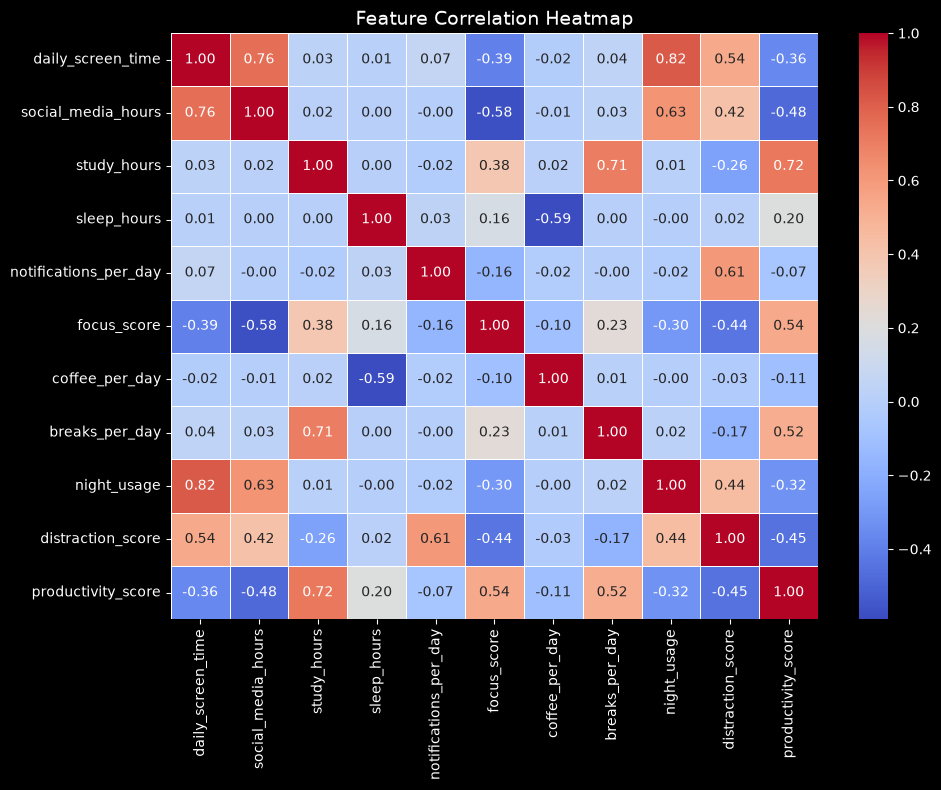

In [94]:
from matplotlib import pyplot as plt

y_pred = rf.predict(X_test_clean)

print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()